# 035 — GM record selection, AvgSA([0, 6]) — Stage 1 (compute)

The slow selection step. Runs the configurable multi-round selection + optimisation engine
(`build_final_ensembles`) to build the final per-`(site, poe)` record ensembles conditioned on
**AvgSA([0, 6])**. Round 2 uses a dict spec (`{"select": ["d"], "optimise": ["d", "vs30"]}`) so
reselection drops only the distance bound while optimisation drops distance + vs30 — reproducing
the legacy AvgSA_06 scheme. **Round 4** is a last-ditch retry: for any `(site, poe)` still failing
after round 3 it re-runs the optimisation over `n_shuffles` shuffled database orderings
(`shuffle = [False, False, False, True]`) and keeps the best-scoring ensemble — a shuffled result
only replaces the incumbent if it passes or scores strictly better, so round 4 can never make a set
worse. First run can take ~an hour; every stage is provenance-cached so re-runs are near-instant.

Each round prints a two-phase summary — a **selection** phase (only sites without a record set yet)
and an **optimisation** phase — labelling the causal bounds as `[bounded: … | unbounded: …]` and
explaining what the work-set of each phase contains (freshly (re)selected vs. carried-over failing
sets, and how many still have no record set at all).

**Upstream**:

| Input | Source |
|---|---|
| GCIM target distributions | `gcim_dist_AvgSA_06.pickle` (nb `034`) |
| Combined selection GM database | `cfg["proc_data"]["gm_database"]` |
| IML-based disaggregations + poe stats | `cfg["proc_data"]["AvgSA_06_disagg_data_gm_selection"]`, `cfg["proc_data"]["AvgSA_06_disagg_stats_gm_selection"]` |
| Site model | `cfg["hazard_models"]["eshm20_wp1_site_model"]` |
| GMM logic tree + correlation flatfiles | loaded inside `setup_AvgSA06_gcim_gm_selection()` |

**Downstream** — `036-gm_selection_AvgSA_06_stage2_postprocess.ipynb` (the fast post-processing
notebook) consumes the canonical `AvgSA_06_final_ensembles.pickle` and re-verifies its manifest.

**Output** (all under `cfg["proc_data"]["gm_selection"]`):
- `AvgSA_06_final_ensembles.pickle` + `.manifest.json` — canonical artifact.
- Per-round stage caches (`AvgSA_06_prelim_selection.pickle`, `..._optimised_selection_rd0N.pickle`,
  …), each provenance-guarded via its own `.manifest.json`.

**Run order** — run top to bottom. Each stage is provenance-cached: if an input (gm_db, gcim
distributions, disagg, site model, params, `rng_seed`, `pickagm` version, round config) changed
since the cache was written it is recomputed automatically; unchanged stages print
`[cache] ... loaded`. Set `FORCE_RECOMPUTE = True` to rebuild every stage + the final artifact. - Slow (several hours)

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pickle
import numpy as np
import pandas as pd

from phd_project.config.config import load_config
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    build_final_ensembles,
    stripe_input_fingerprint,
    find_stale_stripes,
)
from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA06_gm_selection import (
    setup_AvgSA06_gcim_gm_selection,
    SELECTION_CONFIG,
    stripe_source_fps,
)


cfg = load_config()

In [ ]:
# canonical Stage-1 output (per-batch scratch, consumed by the post-processing notebook)
final_ensembles_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_final_ensembles.pickle"

# intermediate stage caches, one per round (provenance-guarded; per-batch scratch)
GMS = cfg["proc_data"]["gm_selection"]
stage_fps = {
    "select": [
        GMS / "AvgSA_06_prelim_selection.pickle",        # round 1 selection (all sites)
        GMS / "AvgSA_06_prelim_reselection.pickle",      # round 2 reselection (no-set sites)
        GMS / "AvgSA_06_prelim_reselection_rd03.pickle", # round 3 reselection (usually none)
        GMS / "AvgSA_06_prelim_reselection_rd04.pickle", # round 4 reselection (usually none)
    ],
    "optimise": [
        GMS / "AvgSA_06_optimised_selection_rd01.pickle",  # round 1 optimise
        GMS / "AvgSA_06_optimised_selection_rd02.pickle",  # round 2 optimise
        GMS / "AvgSA_06_optimised_selection_rd03.pickle",  # round 3 optimise
        GMS / "AvgSA_06_optimised_selection_rd04.pickle",  # round 4 optimise (shuffled)
    ],
}

# inputs used for provenance fingerprinting (hashed by their file bytes)
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / "gcim_dist_AvgSA_06.pickle"
source_fps = {
    "gm_db_file":        cfg["proc_data"]["gm_database"],
    "gcim_file":         gcim_dist_fp,
    "disagg_data_file":  cfg["proc_data"]["AvgSA_06_disagg_data_gm_selection"],
    "disagg_stats_file": cfg["proc_data"]["AvgSA_06_disagg_stats_gm_selection"],
    "site_model_file":   cfg["hazard_models"]["eshm20_wp1_site_model"],
}

# The selection scheme (rounds, bounds, shuffle, seeds, rng_seed) now lives in the
# shared SELECTION_CONFIG (setup_AvgSA06_gm_selection.py) so 034/035/036 fingerprint
# each stripe identically. See that constant for the round-by-round description.

# other stuff:
rng_seed = SELECTION_CONFIG["rng_seed"]

# Escape hatch: force-reselect ALL wanted stripes, ignoring the per-stripe manifests
# (and bypassing every stage's staleness guard). Leave False for normal incremental
# runs: only the stale/new (site, iml) are (re)selected.
FORCE_RECOMPUTE = False

In [ ]:
# set up the record selection
site_iml_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA06_gcim_gm_selection()

# Incremental cache: (re)select only stripes that are missing or stale on disk. Uses
# the same per-stripe fingerprint as 034/036 (excludes the IML subset JSON), so this
# matches the batch nb 034 just built gcim for.
RESULT_FOLDER = cfg["results"]["AvgSA_06_record_selection"]
source_fps_stripe = stripe_source_fps()
wanted = list(site_iml_disaggs.keys())
fp_fn = lambda s, i: stripe_input_fingerprint(
    s, i, source_fps_stripe, basic_selection_ctx, SELECTION_CONFIG)
to_compute, valid = find_stale_stripes(wanted, RESULT_FOLDER, fp_fn)
print(f"{len(wanted)} wanted (site, iml): {len(valid)} already valid, "
      f"{len(to_compute)} to (re)select.")

# load the (complete) gcim distributions written by nb 034
if gcim_dist_fp.is_file():
    with open(gcim_dist_fp, "rb") as file:
        gcim_dists = pickle.load(file)
    print(f"Loaded gcim for {len(gcim_dists)} (site, iml).")
else:
    gcim_dists = {}
    print("No GCIM distribution data found — run nb 034 first.")

## Stage 1 - Build final ensembles (slow compute)

Runs the configurable multi-round selection + optimisation engine and saves the canonical
`AvgSA_06_final_ensembles.pickle` (+ a `.manifest.json` provenance sidecar). Round 2
uses a dict spec so reselection drops only the distance bound while optimisation drops
distance + vs30 - reproducing the legacy AvgSA_06 scheme. **Round 4** re-optimises any
`(site, poe)` still failing after round 3 over `n_shuffles = 5` shuffled database orderings and
keeps the best-scoring ensemble per `(site, poe)` (replaced only if it passes or scores strictly
better). Each step is provenance-cached (changed inputs are recomputed automatically;
`FORCE_RECOMPUTE = True` to rebuild). Each round prints a `[bounded: … | unbounded: …]` bounds
label plus a selection-phase and optimisation-phase breakdown; cached stages print
`[cache] ... loaded`.

Post-processing lives in **`036-gm_selection_AvgSA_06_stage2_postprocess.ipynb`**.

In [ ]:
# Force override: reselect every wanted stripe (ignores the per-stripe manifests).
if FORCE_RECOMPUTE:
    to_compute = list(wanted)

# Subset to the stale batch and run the multi-round engine over just those keys. The
# round loop is per-(site, iml) independent, so selecting a subset is equivalent to
# selecting them within the full set. gcim for every batch key must be present (built
# by nb 034); a missing key means 034 was not run for this batch.
batch = {k: site_iml_disaggs[k] for k in to_compute}
missing = [k for k in batch if k not in gcim_dists]
if missing:
    raise KeyError(
        f"{len(missing)} stale (site, iml) have no gcim — run nb 034 first. "
        f"e.g. {missing[:5]}")

if batch:
    final_ensembles = build_final_ensembles(
        batch,
        disagg_stats,
        gcim_dists,
        gm_db,
        basic_selection_ctx,
        site_model,
        source_fps=source_fps,
        stage_fps=stage_fps,
        output_fp=final_ensembles_fp,
        round_unbounded=SELECTION_CONFIG["round_unbounded"],
        force_optimisation=SELECTION_CONFIG["force_optimisation"],
        shuffle=SELECTION_CONFIG["shuffle"],
        n_shuffles=SELECTION_CONFIG["n_shuffles"],
        shuffle_rng_seeds=SELECTION_CONFIG["shuffle_rng_seeds"],
        rng_seed=rng_seed,
        force_recompute=FORCE_RECOMPUTE,
    )
else:
    final_ensembles = {}
    print("All stripes valid — nothing to (re)select. Run 036 to refresh the CSVs if needed.")

In [ ]:
failing = {k: v for k, v in final_ensembles.items() if v is not None and not v["ks_passed"]}
fks = list(failing.keys())

In [ ]:
# Isolate the (site, iml) in this batch that still fail the KS test after all rounds,
# mapping each to its list of failing IMs. Not pickled - just a quick look at the residual.
failing_ensembles = {
    k: v["ks_failed_ims"]
    for k, v in final_ensembles.items()
    if v is not None and not v["ks_passed"]
}

print(f"{len(failing_ensembles)} (site, iml) still failing:")
for k in failing_ensembles:
    print("  ", k, "->", failing_ensembles[k])

In [8]:
failing[fks[0]].keys()

dict_keys(['recs', 'ks_passed', 'ks_results', 'ks_failed_ims', 'ks_bounds', 'ecdfs', 'quantiles', 'mu_lnIM_recs', 'sig_lnIM_recs', 'cond_imt', 'cond_iml'])

In [9]:
failing[fks[1]]["ks_failed_ims"]

['PGA',
 'SA(0.025)',
 'SA(0.033)',
 'SA(0.045)',
 'SA(0.059)',
 'SA(0.079)',
 'SA(0.597)',
 'SA(6.0)']

['RSD595', 'PGA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.447)', 'SA(0.597)', 'SA(6.0)']


(0.0, 1.0)

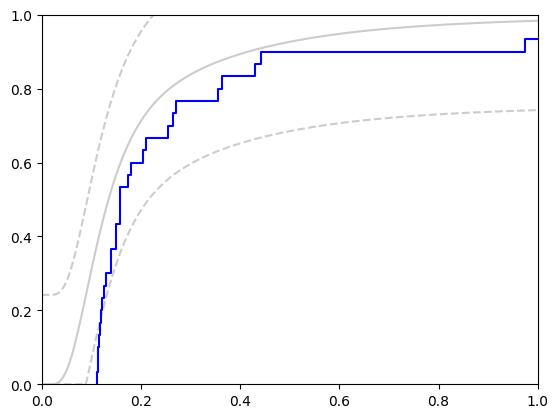

In [14]:
import matplotlib.pyplot as plt
from phd_project.plotting.plotting import plot_im_ecdf_vs_target

idx = 2
im = "PGA"

print(failing[fks[idx]]["ks_failed_ims"])
site_poe = fks[idx]
ecdf = failing[site_poe]["ecdfs"][im]
ks_bounds = failing[site_poe]["ks_bounds"][im]

fig, ax = plt.subplots()

ax = plot_im_ecdf_vs_target(ax, ecdf, ks_bounds)
ax.set_xlim(0, 1)